# 02. Neural Network Classification with PyTorch

Classification is a problem of predicting whether something is one thing or another (there can be multiple things as the options)

## 1. Make classification data and get it ready

In [1]:
import sklearn

In [2]:
from sklearn.datasets import make_circles

# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state=42)


In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
print(f"Frst 5 samples of X\n: {X[:5]}")
print(f"Frst 5 samples of y\n: {y[:5]}")

Frst 5 samples of X
: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
Frst 5 samples of y
: [1 1 1 1 0]


In [5]:
# Make DataFrane of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
                      "X2": X[:, 1],
                      "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


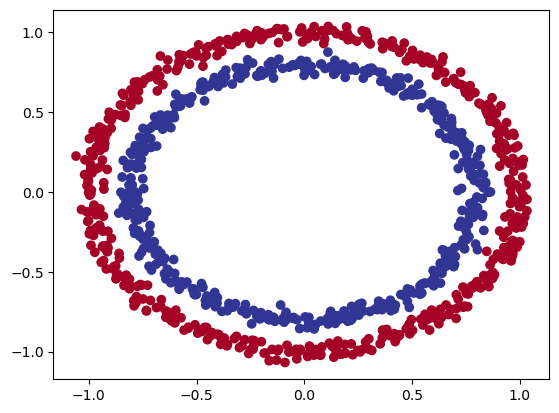

In [6]:
# Visualize
import matplotlib.pyplot as plt
plt.scatter(x = X[:, 0],
            y = X[:, 1],
            c = y,
            cmap = plt.cm.RdYlBu)
plt.show()


**Note:** The data we're working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals

### 1.1 Check input and output shapes

In [7]:
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")


Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


### 1.2 Turn data into tensors and create train and test splits

In [9]:
import torch
torch.__version__


e:\anaconda\envs\sdsd_torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'1.12.1'

In [10]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [11]:
# Split data into training and test sets
from sklearn. model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 20% of data will be test & 80% will be train

In [12]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Building a model

Let's build a model to classify our blue and res dots.

To do so, we want to:
1. Set up device agnostic code so our code will run on an accelerator (GPU) if there is one
2. Construct a model( by subclassing `nn.Module`)
3. Define a loss function and optimizer
4. Create a training and test loop

In [13]:
# impoer pytorch and nn
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [14]:
X_train

tensor([[ 0.6579, -0.4651],
        [ 0.6319, -0.7347],
        [-1.0086, -0.1240],
        ...,
        [ 0.0157, -1.0300],
        [ 1.0110,  0.1680],
        [ 0.5578, -0.5709]])

Now we've setup devide agnostic code, let's create a model that:

1. Subclass `nn.Module` (almost all models in Pytorch subclass `nn.Module`)
2. Crate 2 `nn.Linear` layers that are capable of handling the shapes of our data
3. Defines a `forward()` method that outlines the forward pass (or forward computation) of the model
4. Instatiate an instance of our model class and send it to the target `device`


In [15]:
# 1. Construct a model that subclass nn.Module
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()

        #2. Create 2 nn.Linear capable of handling the shapes of our data
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features and upscales to 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features from previous layer and outputs a single feature (same shape as y)

    # 3. Define a forward() method that outlines the forward pass
    def forward(self, x):
        return self.layer_2(self.layer_1(x)) # x-> layer_1 -> layer_2 -> output

# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV0().to(device)
model_0


CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [16]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [17]:
# Let's replicate the model above using nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [18]:
# Make predictions
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, shape: {X_test.shape}")
print(f"\nFirst 10 predictions: \n{untrained_preds[:10]}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, shape: torch.Size([200, 1])
Length of test samples: 200, shape: torch.Size([200, 2])

First 10 predictions: 
tensor([[-0.9660],
        [-0.9547],
        [-0.7507],
        [-1.0280],
        [-0.3618],
        [-0.3579],
        [-0.6343],
        [-0.4936],
        [-0.7674],
        [-0.9496]], device='cuda:0')

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


### 2.1 Setup loss function and optimizer

Which loss function or optimizer should you use?

Again... this is problem specific.

For example for regression you might MAE OR MSE (mean absolute error or mean squared error)

For classification you might want binary cross entropy or categorical cross entropy (cross entropy)

As a reminder, the loss functino measures how *wrong* your models predictions are

And for optimizers, two of the most common and useful are SGD and Adam, however Pytorch has lots of other options.

* For the loss function we're going to use `torch.nn.BCEWithLogitsLoss`.

In [19]:
# Setup the loss function
# loss_fn = nn.BCELoss() # BCELoss = requires inputs to have gone through the sigmoid activatiion function prior to input to BCELoss
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid activation function built-in

optimizer = torch.optim.SGD(params= model_0.parameters(),
                            lr= 0.1)

In [20]:
# Calculate accuracy - out of 100 examples, what percentage does our model get right?
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

### 3. Train model

To train our model, we're going to need to build a training loop:

1. Forward pass
2. Calculate loss
3. Optimizer zero grad
4. Loss backward(backpropagation)
5. Optimizer step(gradient descent)

### 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw **logits**

we can convert these **logits** into **prediction probabilities** by passing them to some kind of activation function (e.g. sigmoid for binary classification and softmax for multiclass classification)

Then we can convert our model's prediction probabilities to **prediction labels** by either rounding them or taking the `argmax()`.

In [21]:
# View the first 5 ouputs of forward pass on the test data
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test.to(device))[:5]
y_logits


tensor([[-0.9660],
        [-0.9547],
        [-0.7507],
        [-1.0280],
        [-0.3618]], device='cuda:0')

In [22]:
# Use sigmoid activation function on our model logits to turn them into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.2757],
        [0.2779],
        [0.3207],
        [0.2635],
        [0.4105]], device='cuda:0')

For our prediction probability values, we need perform a range-style rounding on them:
* `y_prd_probs` >=0.5, `y=1`(class 1)
* `y_prd_probs` <0.5, `y=0`(class 0)

In [23]:
# Find the predicted labels
y_preds = torch.round(y_pred_probs)

# In full (logits -> pred probs -> pred labels)
y_preds_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_preds_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()


tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 0.], device='cuda:0')

### 3.2 Building a training and testing loop

In [24]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Build training and evaluation loop
for epoch in range(epochs):
    ### Training
    model_0.train()

    # 1. Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels

    # 2. Calculate loss/accuracy
    # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss expects prediction probabilities as input
    #                y_train)
    loss = loss_fn(y_logits, # nn.BCEWithLogitsLoss() expects raw logits as input
                   y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backward (backpropagation)
    loss.backward()

    # 5. Optimizer step (gradient descent)
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        # 2. Calculate test loss/acc
        test_loss = loss_fn(test_logits,
                            y_test)
        test_acc = accuracy_fn(y_true=y_test,
                                y_pred=test_pred)

    # Print out what's happening
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.5f} | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.75619 | Acc: 50.00000 | Test loss: 0.74772 | Test acc: 50.00%
Epoch: 10 | Loss: 0.71510 | Acc: 50.00000 | Test loss: 0.71032 | Test acc: 50.00%
Epoch: 20 | Loss: 0.70177 | Acc: 40.50000 | Test loss: 0.69829 | Test acc: 45.50%
Epoch: 30 | Loss: 0.69725 | Acc: 47.50000 | Test loss: 0.69435 | Test acc: 48.00%
Epoch: 40 | Loss: 0.69555 | Acc: 48.62500 | Test loss: 0.69302 | Test acc: 49.00%
Epoch: 50 | Loss: 0.69480 | Acc: 48.75000 | Test loss: 0.69255 | Test acc: 50.00%
Epoch: 60 | Loss: 0.69439 | Acc: 49.12500 | Test loss: 0.69239 | Test acc: 50.50%
Epoch: 70 | Loss: 0.69412 | Acc: 49.37500 | Test loss: 0.69234 | Test acc: 49.50%
Epoch: 80 | Loss: 0.69393 | Acc: 50.00000 | Test loss: 0.69234 | Test acc: 50.00%
Epoch: 90 | Loss: 0.69378 | Acc: 49.50000 | Test loss: 0.69237 | Test acc: 51.00%
Epoch: 100 | Loss: 0.69366 | Acc: 50.25000 | Test loss: 0.69241 | Test acc: 51.00%
Epoch: 110 | Loss: 0.69356 | Acc: 50.12500 | Test loss: 0.69246 | Test acc: 51.50%
Epoch: 120 | Lo

## 4. Make predictions and evaluate the model

From the metrics,it looks like our model isn't learning anything...

So to inspect it let's make some predictions and make them visual!

To do so, we're going to import a function called `plot_decision_boundary()`

In [25]:
import requests
from pathlib import Path

# Download helper functions from Learn Pytorch repo (if it's not already downloaded)
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Download helper_functions.py")
    requests = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(requests.content)

from helper_functions import plot_decision_boundary, plot_predictions


helper_functions.py already exists, skipping download


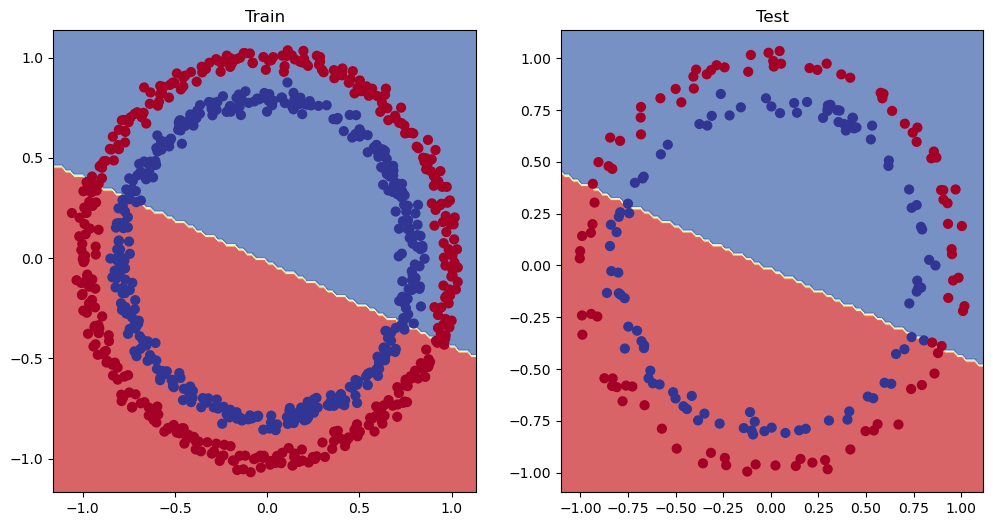

In [26]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

## 5. Impoving a model (from a model perspective)

* Add more layers - give the model more chances to learn about patterns in the data
* Add more hidden units - go from 5 hidden units to 10 hidden units
* Fit for longer
* Changing the activation functions
* Change the learning rate
* Change the loss function

These options are all from a model's perspective because they deal directly with the model, rather than the data.

And because these options are all values we (as machine learning engineers and data scientists) can change, they are referred as **hyperparameters**.

Let's try and improve our model by:
* Adding more hidden units: 5->10
* Increase the number of layers : 2->3
* Increase the number of epochs : 100->1000

In [27]:
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x):
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        return self.layer_3(self.layer_2(self.layer_1(x))) # this way of writing operations leverages speed ups where possible behind the scenes

model_1 = CircleModelV1().to(device)
model_1


CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [28]:
# Create a loss function
loss_fn = nn.BCEWithLogitsLoss()

# Create an optimizer
optimizer = torch.optim.SGD(model_1.parameters(), lr=0.1)

In [29]:
# Write a training and evaluation loop for model_1
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Train for longer
epochs = 1000

# Put data on the target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    ### Training
    model_1.train()

    # 1. Forward pass
    y_logits = model_1(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))

    # 2. Compute loss/acc
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_preds)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Backward pass
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_y_logits = model_1(X_test).squeeze()
        test_y_pred = torch.round(torch.sigmoid(test_y_logits))

        # 2. Calculate loss
        test_loss = loss_fn(test_y_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_y_pred)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")
    

Epoch: 0 | Loss: 0.69396 | Acc: 50.88% | Test loss: 0.69261 | Test acc: 51.00%
Epoch: 10 | Loss: 0.69369 | Acc: 50.25% | Test loss: 0.69270 | Test acc: 50.00%
Epoch: 20 | Loss: 0.69351 | Acc: 50.12% | Test loss: 0.69283 | Test acc: 49.50%
Epoch: 30 | Loss: 0.69339 | Acc: 50.50% | Test loss: 0.69297 | Test acc: 48.00%
Epoch: 40 | Loss: 0.69329 | Acc: 50.38% | Test loss: 0.69310 | Test acc: 49.00%
Epoch: 50 | Loss: 0.69322 | Acc: 49.88% | Test loss: 0.69324 | Test acc: 50.00%
Epoch: 60 | Loss: 0.69317 | Acc: 49.38% | Test loss: 0.69336 | Test acc: 51.50%
Epoch: 70 | Loss: 0.69312 | Acc: 49.38% | Test loss: 0.69348 | Test acc: 50.50%
Epoch: 80 | Loss: 0.69309 | Acc: 50.12% | Test loss: 0.69359 | Test acc: 50.00%
Epoch: 90 | Loss: 0.69307 | Acc: 50.50% | Test loss: 0.69370 | Test acc: 48.50%
Epoch: 100 | Loss: 0.69305 | Acc: 50.38% | Test loss: 0.69379 | Test acc: 48.00%
Epoch: 110 | Loss: 0.69303 | Acc: 50.88% | Test loss: 0.69388 | Test acc: 46.50%
Epoch: 120 | Loss: 0.69302 | Acc: 50.75

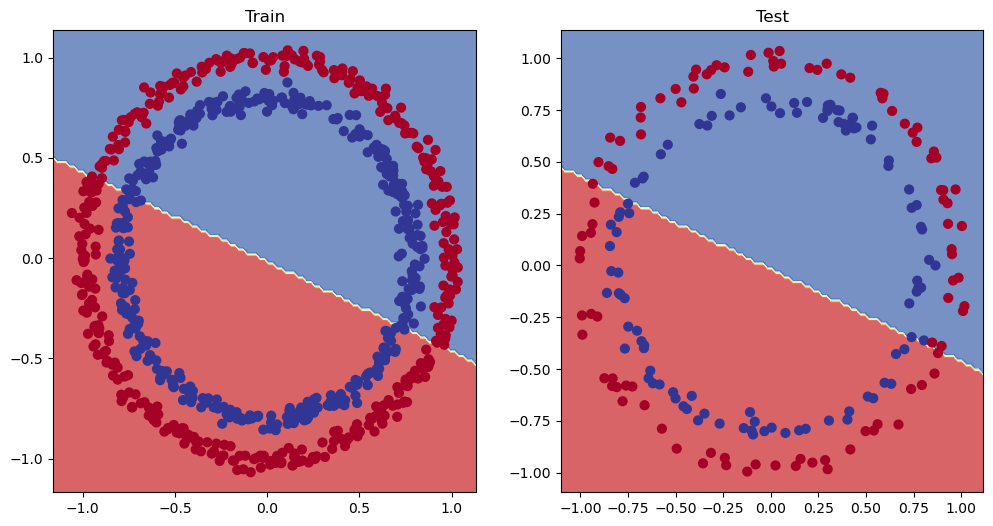

In [30]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

### 5.1 Preparing data to see if our model can fit a straight line

One way to troubleshoot to a large problem is to test out a smaller problem

In [31]:
# Create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(1)
y_regression = X_regression * weight + bias # Linear regression formula (without epsilon)

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]


100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [32]:
# Create train and test splits
train_splits = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_splits], y_regression[:train_splits]
X_test_regression, y_test_regression = X_regression[train_splits:], y_regression[train_splits:]

# Check the length of each
len(X_train_regression), len(X_test_regression), len(y_train_regression), len(y_test_regression)

(80, 20, 80, 20)

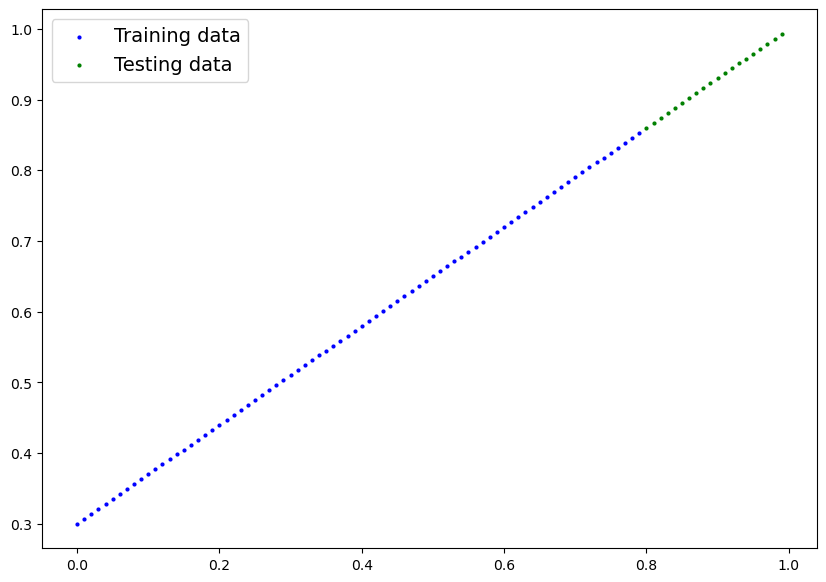

In [33]:
plot_predictions(train_data=X_train_regression, 
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression)


### 5.2 Adjusting `model_1` to fit a straight line



In [34]:
# Same architecture as model_1 (but using nn.Sequential())
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [35]:
# Loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [36]:
# Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put the data on the target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

# Training
for epoch in range(epochs):
    y_pred = model_2(X_train_regression)
    loss = loss_fn(y_pred, y_train_regression)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Testing
    model_2.eval()
    with torch.inference_mode():
        test_pred = model_2(X_test_regression)
        test_loss = loss_fn(test_pred, y_test_regression)

    # Print out what's happening
    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f}")


Epoch: 0 | Loss: 0.7599 | Test Loss: 0.9110
Epoch: 100 | Loss: 0.0286 | Test Loss: 0.0008
Epoch: 200 | Loss: 0.0253 | Test Loss: 0.0021
Epoch: 300 | Loss: 0.0214 | Test Loss: 0.0031
Epoch: 400 | Loss: 0.0196 | Test Loss: 0.0034
Epoch: 500 | Loss: 0.0194 | Test Loss: 0.0039
Epoch: 600 | Loss: 0.0190 | Test Loss: 0.0038
Epoch: 700 | Loss: 0.0188 | Test Loss: 0.0038
Epoch: 800 | Loss: 0.0184 | Test Loss: 0.0033
Epoch: 900 | Loss: 0.0180 | Test Loss: 0.0036


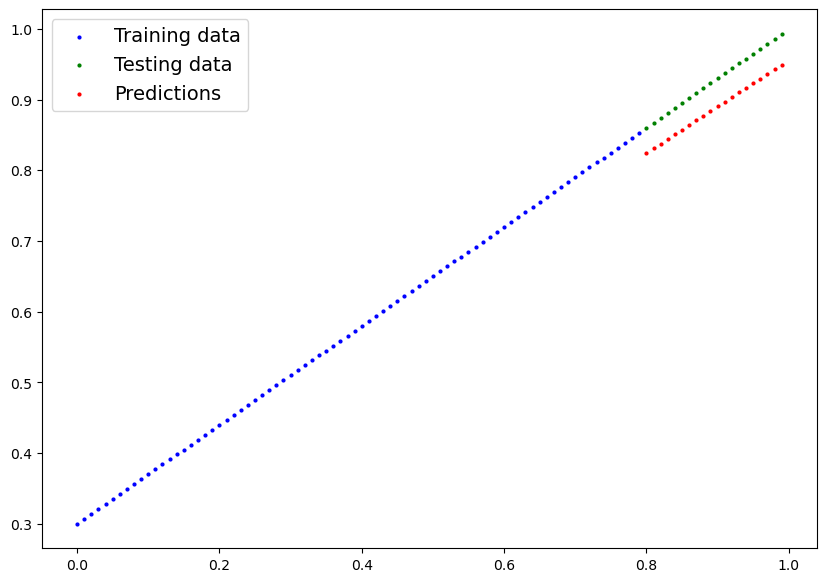

In [37]:
# Turn on evaluation mode
model_2.eval()

# Make predictions (inference mode)
with torch.inference_mode():
    y_preds = model_2(X_test_regression)

# Plot data and predictions
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu())


## 6. The missing piece: non-linearity

"What patterns could you draw if you were given an infinite amount of a straight and non-straight lines?"

Or in machine learning terms, an infinite (but really it is finite) of linear and non-linear functions?

### 6.1 Recreating non-linear data(red and blue circles)

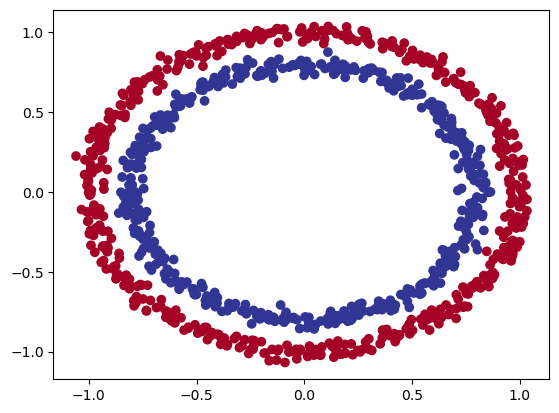

In [38]:
# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X,y = make_circles(n_samples,
                   noise = 0.03,
                   random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, cmap = plt.cm.RdYlBu)

In [39]:
# Convert data to tensors and then to train and test splits
import torch
from sklearn.model_selection import train_test_split

# Turn data tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building a model with non-linearity

Artificial neural networks are a large combination of linear (straight) and non-linear functions which are potentially able to find patterns in data.

In [40]:
# Build a model with non-linearity
from torch import nn
class CircleModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU() # relu is a non-linear activation function

    def forward(self, x):
        # Where should we put our non-linear activation function?
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [41]:
# Setup loss and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(), lr=0.1)

### 6.3 Training a model with non-linearity

In [42]:
# Random seeds 
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Train model_3

epochs = 2000

for epoch in range(epochs):
    model_3.train()
    # 1. Forward pass
    y_model_3_logits = model_3(X_train).squeeze()
    y_model_3_preds = torch.round(torch.sigmoid(y_model_3_logits))

    # 2. Calculate loss
    loss = loss_fn(y_model_3_logits, y_train)
    acc = accuracy_fn(y_true=y_model_3_preds, y_pred=y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Backward pass
    loss.backward()

    # 5. Optimizer step
    optimizer.step()

    # Testing
    model_3.eval()
    with torch.inference_mode():
        y_model_3_test_logits = model_3(X_test).squeeze()
        y_model_3_test_preds = torch.round(torch.sigmoid(y_model_3_test_logits))

        test_loss = loss_fn(y_model_3_test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_model_3_test_preds, y_pred=y_test)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Train Acc: {acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
       

Epoch: 0 | Train Loss: 0.6929 | Train Acc: 50.0000 | Test Loss: 0.6932 | Test Acc: 50.0000
Epoch: 10 | Train Loss: 0.6925 | Train Acc: 50.5000 | Test Loss: 0.6926 | Test Acc: 50.0000
Epoch: 20 | Train Loss: 0.6922 | Train Acc: 59.1250 | Test Loss: 0.6923 | Test Acc: 56.5000
Epoch: 30 | Train Loss: 0.6921 | Train Acc: 70.2500 | Test Loss: 0.6921 | Test Acc: 68.0000
Epoch: 40 | Train Loss: 0.6919 | Train Acc: 68.3750 | Test Loss: 0.6919 | Test Acc: 71.0000
Epoch: 50 | Train Loss: 0.6918 | Train Acc: 58.2500 | Test Loss: 0.6918 | Test Acc: 58.0000
Epoch: 60 | Train Loss: 0.6917 | Train Acc: 54.0000 | Test Loss: 0.6916 | Test Acc: 54.5000
Epoch: 70 | Train Loss: 0.6915 | Train Acc: 53.1250 | Test Loss: 0.6915 | Test Acc: 53.0000
Epoch: 80 | Train Loss: 0.6914 | Train Acc: 52.6250 | Test Loss: 0.6913 | Test Acc: 53.0000
Epoch: 90 | Train Loss: 0.6913 | Train Acc: 52.7500 | Test Loss: 0.6912 | Test Acc: 53.0000
Epoch: 100 | Train Loss: 0.6912 | Train Acc: 52.8750 | Test Loss: 0.6910 | Test A

### 6.4 Evaluating a model trained with non-linear activation functions

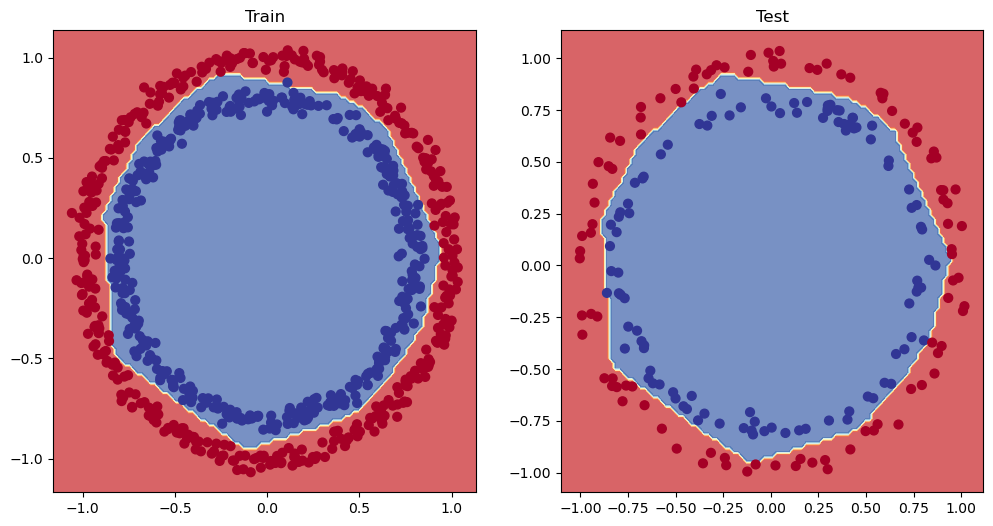

In [43]:
# Plot decision boundary of the model
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test)

## 7. Replicating non-linear activation functions

Neural networks, rather rthan us telling the model what to learn, we give it the tools to discover patterns in data and it tries to figure out the patterns on its own.

And these tools are linear & non-linear functions

In [44]:
# Create a tensor
A = torch.arange(-10, 10, 1, dtype=torch.float32)

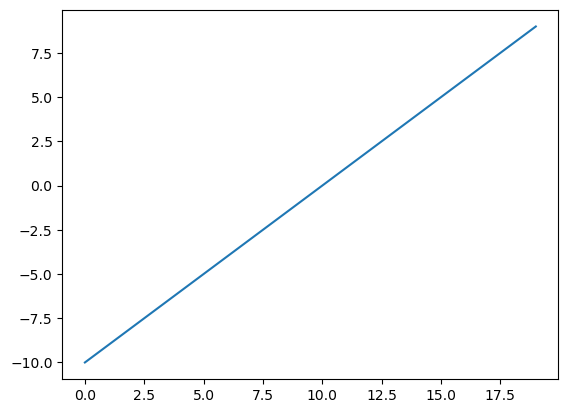

In [45]:
# Visualize the tensor
plt.plot(A)

In [46]:
def relu(x) -> torch.Tensor:
    return torch.maximum(torch.tensor(0), x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

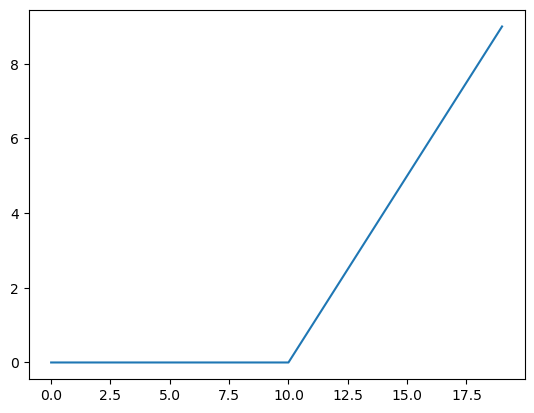

In [47]:
plt.plot(relu(A))
plt.show()

In [48]:
# Now let's do same for sigmoid function
def sigmoid(x) -> torch.Tensor:
    return 1 / (1 + torch.exp(-x))

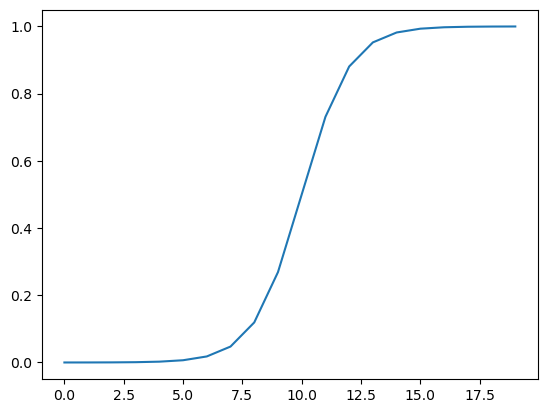

In [49]:
plt.plot(torch.sigmoid(A))

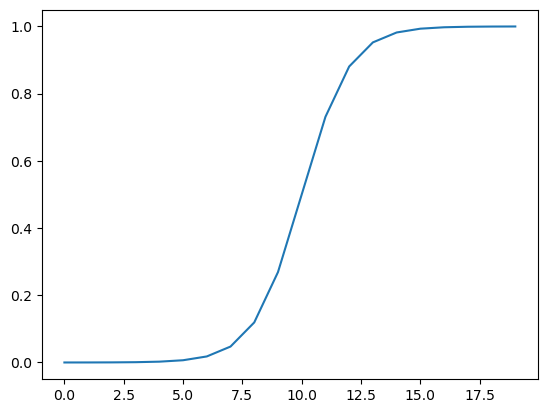

In [50]:
plt.plot(torch.sigmoid(A))
plt.show()

## 8. Putting it all together with a multi-class classification problem



### 8.1 Creating a toy multi-class dataset

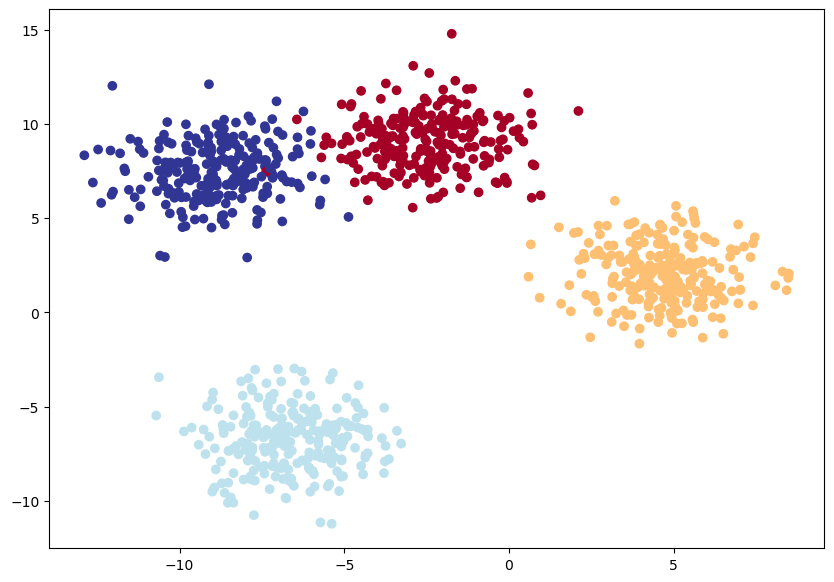

In [51]:
# Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_STATE = 42

# 1. Create multi-class data
X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std = 1.5,
                            random_state=RANDOM_STATE)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float32)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# 3. Split into train and test
X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size=0.2, random_state=RANDOM_STATE)

# 4. Plot data(visualize)
plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap=plt.cm.RdYlBu)
plt.show()

### 8.2 Building a multi-class classification model in Pytorch

In [52]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [53]:
# Build a multi-class classification model
class BlobModel(torch.nn.Module):
    def __init__(self, input_features, output_features, hidden_units=8):
        """Initializes multi-class classification model.
        
        Args:
            input_features (int): Number of input features to the model.
            output_features (int): Number of output features (number of output classes).
            hidden_features (int): Number of hidden units between layers, default 8.
        Returns:
            None
        Example:
        """
        super().__init__()
        self.linear_layer_stack = torch.nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )

    def forward(self, x):
        return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(input_features=2, 
                    output_features=4, 
                    hidden_units=8).to(device)
model_4

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

### 8.3 Create a loss function and an optimizer for a multi-class classification model

In order to evaluate and train and test our model, we need to convert our model's outputs (logits) to prediction probabilities and then to prediction lables.

Logits (raw output of the model) -> Pred probs(use `torch.softmax`) -> Pred labels (take the argmax of the prediction probabilities)

In [54]:
# Create a loss function for multi-class classification
loss_fn = nn.CrossEntropyLoss()

# Create an optimizer for multi-class classification
optimizer = torch.optim.SGD(model_4.parameters(), 
                            lr=0.01)


### 8.4 Getting prediction probabilities for a multi-class Pytorch model

In [55]:
# Ley's get some raw outputs of our model(logits)
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test.to(device))
y_logits

tensor([[-7.6459e-01, -7.4120e-01, -1.5777e+00, -1.1376e+00],
        [-9.7256e-02, -9.4310e-01, -5.9631e-01, -1.3715e-01],
        [ 2.5277e-01, -2.3794e-01,  1.8817e-01, -6.5686e-03],
        [-4.1340e-01, -5.2042e-01, -9.3033e-01, -6.9626e-01],
        [-3.1184e-01, -1.3736e+00, -1.1991e+00, -3.8337e-01],
        [-1.4971e-01, -1.0617e+00, -7.1069e-01, -1.6452e-01],
        [ 1.5388e-01, -2.8874e-01,  1.5199e-01, -1.0874e-02],
        [-2.1543e-01, -1.1795e+00, -9.3000e-01, -2.7448e-01],
        [ 2.4432e-01, -2.4716e-01,  1.6492e-01,  6.1044e-03],
        [-2.3286e-01, -1.2120e+00, -9.8487e-01, -3.0037e-01],
        [-1.7742e-01, -1.1008e+00, -8.2929e-01, -2.3689e-01],
        [-9.4082e-01, -7.8985e-01, -1.8480e+00, -1.3347e+00],
        [-2.9723e-01, -1.3458e+00, -1.1543e+00, -3.6287e-01],
        [-2.9006e-01, -1.3393e+00, -1.1146e+00, -3.3518e-01],
        [-3.3713e-01, -1.4374e+00, -1.2379e+00, -3.8029e-01],
        [-1.0260e-01, -9.5066e-01, -6.1913e-01, -1.5105e-01],
        

In [56]:
# Convert our model's logit outputs to prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs

tensor([[0.3169, 0.3244, 0.1405, 0.2182],
        [0.3336, 0.1432, 0.2026, 0.3206],
        [0.3011, 0.1843, 0.2823, 0.2323],
        [0.3078, 0.2766, 0.1836, 0.2320],
        [0.3719, 0.1286, 0.1532, 0.3463],
        [0.3381, 0.1358, 0.1929, 0.3331],
        [0.2867, 0.1841, 0.2861, 0.2431],
        [0.3554, 0.1355, 0.1740, 0.3351],
        [0.3009, 0.1841, 0.2779, 0.2371],
        [0.3595, 0.1350, 0.1695, 0.3360],
        [0.3496, 0.1389, 0.1822, 0.3294],
        [0.3085, 0.3588, 0.1246, 0.2081],
        [0.3688, 0.1292, 0.1565, 0.3454],
        [0.3644, 0.1276, 0.1598, 0.3483],
        [0.3708, 0.1234, 0.1506, 0.3551],
        [0.3358, 0.1438, 0.2004, 0.3200],
        [0.3332, 0.1429, 0.2029, 0.3209],
        [0.2996, 0.1844, 0.2712, 0.2448],
        [0.3450, 0.1320, 0.1827, 0.3403],
        [0.3284, 0.1473, 0.2110, 0.3133],
        [0.3434, 0.1366, 0.1875, 0.3325],
        [0.3436, 0.1464, 0.1930, 0.3170],
        [0.3120, 0.2068, 0.2453, 0.2359],
        [0.2962, 0.1830, 0.2844, 0

In [57]:
# Convert our model's prediction probabilities to prediction labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds

tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 1, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1], device='cuda:0')

### 8.5 Creating a training loop and testing loop for a multi-class Pytorch model

In [58]:
# Fit the multi-class model to the data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
epochs = 200

# Put data to the target device
X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device)

# Loop through data
for epoch in range(epochs):
    ### training
    model_4.train()

    y_logits = model_4(X_blob_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train,
                      y_pred=y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### Testing
    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(X_blob_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test,
                              y_pred=test_preds)
    # Print out
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.4f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")


Epoch: 0 | Train Loss: 1.1588 | Train Acc: 40.38% | Test Loss: 1.1472 | Test Acc: 38.50%
Epoch: 10 | Train Loss: 1.0649 | Train Acc: 55.38% | Test Loss: 1.0684 | Test Acc: 50.50%
Epoch: 20 | Train Loss: 0.9819 | Train Acc: 62.62% | Test Loss: 0.9976 | Test Acc: 57.50%
Epoch: 30 | Train Loss: 0.9114 | Train Acc: 70.50% | Test Loss: 0.9360 | Test Acc: 67.00%
Epoch: 40 | Train Loss: 0.8529 | Train Acc: 88.38% | Test Loss: 0.8834 | Test Acc: 87.50%
Epoch: 50 | Train Loss: 0.8043 | Train Acc: 92.12% | Test Loss: 0.8385 | Test Acc: 93.00%
Epoch: 60 | Train Loss: 0.7635 | Train Acc: 93.62% | Test Loss: 0.7998 | Test Acc: 94.50%
Epoch: 70 | Train Loss: 0.7285 | Train Acc: 94.88% | Test Loss: 0.7659 | Test Acc: 95.00%
Epoch: 80 | Train Loss: 0.6977 | Train Acc: 95.62% | Test Loss: 0.7356 | Test Acc: 95.00%
Epoch: 90 | Train Loss: 0.6698 | Train Acc: 96.38% | Test Loss: 0.7076 | Test Acc: 96.50%
Epoch: 100 | Train Loss: 0.6438 | Train Acc: 96.88% | Test Loss: 0.6812 | Test Acc: 97.00%
Epoch: 110

### 8.6 Making and evaluating predictions with a pytorch multi-class model

In [59]:
# Make predictions
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

# View the first 10 predictions
y_logits[:10]

tensor([[-1.3339e+00,  2.7124e+00, -4.1024e+00, -3.9630e+00],
        [-3.0859e-01, -3.4431e+00, -3.0202e+00,  7.0692e-01],
        [ 3.1554e-03, -4.5208e-01,  5.0277e-01, -1.3561e-01],
        [-9.9173e-01,  1.9686e+00, -2.1182e+00, -2.3882e+00],
        [ 7.4186e-01, -2.2668e+00, -4.9273e+00, -1.7737e+00],
        [-4.6710e-01, -3.9935e+00, -3.5178e+00,  9.3605e-01],
        [-2.0809e-02, -3.8264e-01,  4.5658e-01, -7.9712e-02],
        [ 6.2890e-01, -3.2703e+00, -3.9074e+00, -6.5442e-01],
        [-1.1562e-01, -6.8801e-01,  3.8269e-01, -2.7254e-01],
        [ 7.6747e-01, -3.0855e+00, -4.0841e+00, -9.4996e-01]], device='cuda:0')

In [60]:
# Go from logits -> Prediction probabilities
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:10]

tensor([[0.0171, 0.9805, 0.0011, 0.0012],
        [0.2584, 0.0112, 0.0172, 0.7132],
        [0.2408, 0.1527, 0.3969, 0.2096],
        [0.0479, 0.9247, 0.0155, 0.0119],
        [0.8821, 0.0435, 0.0030, 0.0713],
        [0.1944, 0.0057, 0.0092, 0.7907],
        [0.2352, 0.1638, 0.3792, 0.2218],
        [0.7645, 0.0155, 0.0082, 0.2118],
        [0.2460, 0.1388, 0.4049, 0.2103],
        [0.8274, 0.0176, 0.0065, 0.1485]], device='cuda:0')

In [61]:
# Go from pred probs to pred labels
y_preds = torch.argmax(y_pred_probs, dim=1)
y_preds[:10]

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0], device='cuda:0')

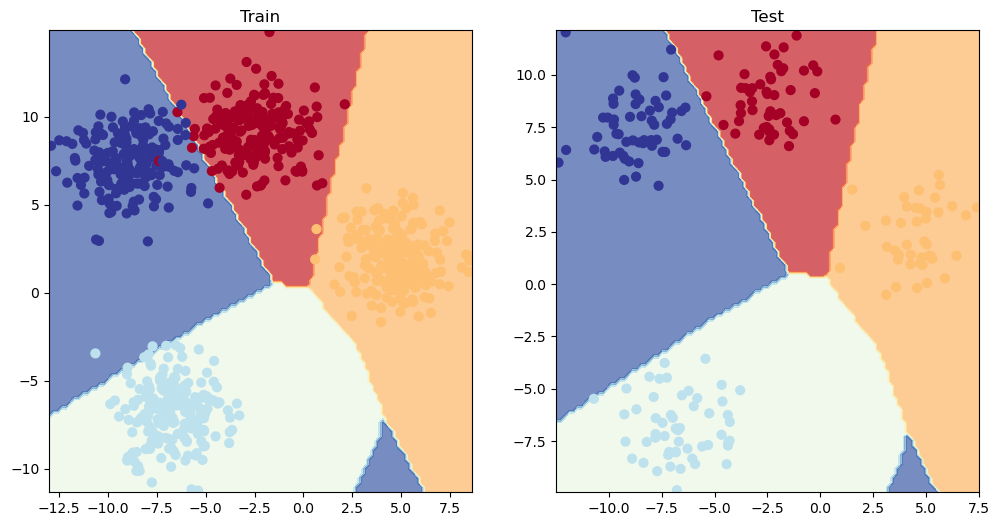

In [62]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

## 9. A few more classification metrics...(to evaluate our classification model)

* Accuracy - out of 100 samples, how many does our model get right
* Precision
* Recall
* F1-score
* Confusion matrix
* Classification report

In [70]:
from torchmetrics import Accuracy

# Setup metric
torchmetrics_accuracy = Accuracy(task="multiclass", num_classes=4).to(device)

# Calculate accuracy
torchmetrics_accuracy(y_preds, y_blob_test)

tensor(1., device='cuda:0')